In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
import random
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import A2C
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay


from stable_baselines3 import DQN
from stable_baselines3 import A2C
from stable_baselines3 import PPO
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [ ]:
papersdf= pd.read_csv('../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv')
papersdf

,title,publication_year,cited_by_count,topics.display_name,topics.score,cited_by_count_norm,publication_year_norm,publication_year_quartile,cited_by_count_quartile,log_cite
0,How to conduct a bibliometric analysis: An ove...,2021,6635,['scientometrics and bibliometrics research'],[0.9736],1.000000,0.996341,0.838384,1.000000,8.800265
1,Analyzing the past to prepare for the future: ...,2002,6002,"['scientometrics and bibliometrics research', ...","[0.8112, 0.8084, 0.7988]",0.987637,0.978037,0.196970,1.000000,8.700015
2,Co‐citation in the scientific literature: A ne...,1973,4591,['scientometrics and bibliometrics research'],[0.9994],0.954593,0.946613,0.118967,1.000000,8.432071
3,"Comparison of PubMed, Scopus, Web of Science, ...",2007,3769,"['scientometrics and bibliometrics research', ...","[0.9943, 0.9924, 0.9793]",0.930270,0.983010,0.247475,0.998102,8.234830
4,The journal coverage of Web of Science and Sco...,2015,3167,"['scientometrics and bibliometrics research', ...","[0.9994, 0.9448, 0.9224]",0.908817,0.990731,0.570707,0.996712,8.060856
...,...,...,...,...,...,...,...,...,...,...
50022,Issue Publication Information,2018,0,['scientometrics and bibliometrics research'],[0.5676],0.000000,0.993555,0.737374,0.000000,0.000000
50023,W. A. TAYLOR and CO.,1961,0,"['scientometrics and bibliometrics research', ...","[0.8668, 0.8155, 0.7664]",0.000000,0.932099,0.101010,0.000000,0.000000
50024,VARIAN associates,1962,0,"['scientometrics and bibliometrics research', ...","[0.2804, 0.2517]",0.000000,0.933348,0.103030,0.000000,0.000000
50025,scientific products,1963,0,['scientometrics and bibliometrics research'],[0.315],0.000000,0.934589,0.105051,0.000000,0.000000


In [108]:
papersdf[papersdf['cited_by_count_quartile'] < 0.5].cited_by_count.value_counts()

cited_by_count
0    22524
Name: count, dtype: int64

In [109]:
papersdf[papersdf['cited_by_count_quartile'] < 0.5].shape[0]/papersdf.shape[0]

0.4502368720890719

In [104]:
papersdf[papersdf.publication_year_quartile>=0.9].publication_year.value_counts()

publication_year
2023    3506
2024    2140
2025     332
Name: count, dtype: int64

In [105]:
papersdf[papersdf.publication_year_quartile>=0.9].shape[0]/ papersdf.shape[0]

0.11949547244487976

## A2C

In [2]:
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
eval_users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
all_users = eval_users_loader.get_users()

reward_shaping = CitationRewardReshapingExpDecay()
selector = CitationsSelector()

env = UserEnv(
        render_mode= "human",
        debug=False,
        items_loader=paper_loader,
        user_list=all_users,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,  # <- Match what the model was trained on
        render_path="./tmp/render/",
)
env = Monitor(env, filename=f"A2C150000_alluser_random", info_keywords=("user_id", "item_interact", "item_clicks"))
model = A2C.load("models/A2C_citation_recommender_baseline_150000", env=env, device="cpu")

Wrapping the env in a DummyVecEnv.


In [116]:
import numpy as np
K=10
def recommend_k_paper(env, agent, K=10, num_users=5):
    # rec = {}
    infos = {}
    for user_idx in range(num_users):
        obs, info = env.reset(user_id=user_idx)
        # print(obs)
        done = False
        
        user_id = info['user_id']
        
        recommended_items = list()
        while len(recommended_items) < K:
            obs = {k: np.array([v]) for k, v in obs.items()}
            action, _ = agent.predict(obs)
            action = int(action)
            recommended_items.append(action)
        
            obs, _, done, _, info = env.step(action)
            infos[user_id] = info
            if done:
                obs, info = env.reset(user_id=user_idx)

    return infos


# Simulate user clicks
def simulate_user_clicks(model, env=env, K=K, all_users=all_users):
    recommended_papers = []
    history_for_all_sessions= []
    for _ in range(50):
        print(_)
        infos = recommend_k_paper(env, model, K=K, num_users=len(all_users))
        # recommended_papers.append(recs)
        history = {}
        papers ={}

        for user_id, info in infos.items():
            user = [i for i in all_users if i.id == user_id][0]
            history[user_id] = info['item_clicks']
            papers[user_id] = info['item_interact']
        history_for_all_sessions.append(history)
        recommended_papers.append(papers)

    return recommended_papers, history_for_all_sessions


reccommended_papers, history_for_all_sessions = simulate_user_clicks(model)
history_for_all_sessions

0


/var/folders/_f/s0xx4_bj711c1h8k9b5vjhgm0000gn/T/ipykernel_87846/2804152994.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


Final score: (0.6428496364673479 + 0.6033333333333333 + 0.75) / 3 = 0.6653943232668937
user = 0 - action = 37086 - rating = 0.6653943232668937 - click = 1 - interact_num = 1 - reward = 1.3307886465337875
Final score: (0.6165959281282052 + 0.34 + 0.75) / 3 = 0.5688653093760684
user = 0 - action = 34424 - rating = 0.5688653093760684 - click = 1 - interact_num = 1 - reward = 1.1377306187521368
Final score: (0.2469674383872449 + 0 + 0) / 3 = 0.08232247946241496
user = 0 - action = 25777 - rating = 0.08232247946241496 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.5074184859681825 + 0 + 0) / 3 = 0.1691394953227275
user = 0 - action = 49891 - rating = 0.1691394953227275 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.18365329181607848 + 0 + 0) / 3 = 0.061217763938692826
user = 0 - action = 37846 - rating = 0.061217763938692826 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6532864991488943 + 0.5733333333333334 + 0.8952020202020202) / 3 = 0.70727

[{0: (1, 1, 0, 0, 0, 1, 0, 1, 0, 0),
  1: (1, 1, 0, 1, 1, 1, 0, 0, 0, 1),
  2: (1, 1, 0, 1, 0, 0, 0, 1, 0, 1),
  3: (1, 1, 1, 0, 0, 1, 1, 0, 1, 0),
  4: (0, 0, 0, 1, 1, 1, 0, 1, 0, 0),
  5: (1, 1, 1, 0, 1, 0, 1, 1, 0, 1),
  6: (1, 0, 0, 0, 1, 1, 0, 1, 1, 1),
  7: (0, 1, 1, 0, 0, 1, 1, 1, 0, 1),
  8: (1, 1, 1, 0, 1, 0, 0, 1, 0, 1)},
 {0: (0, 1, 0, 0, 1, 0, 0, 1, 0, 0),
  1: (0, 1, 1, 0, 1, 1, 0, 0, 1, 1),
  2: (1, 0, 0, 1, 1, 1, 1, 0, 1, 1),
  3: (0, 1, 0, 1, 0, 1, 0, 0, 0, 1),
  4: (1, 1, 1, 1, 0, 1, 0, 1, 1, 1),
  5: (1, 1, 0, 1, 1, 1, 0, 0, 0, 1),
  6: (0, 1, 0, 0, 1, 0, 1, 0, 0, 0),
  7: (1, 0, 0, 0, 0, 1, 0, 1, 1, 0),
  8: (1, 0, 1, 1, 0, 1, 0, 0, 1, 0)},
 {0: (1, 1, 1, 1, 0, 1, 0, 0, 0, 0),
  1: (1, 1, 1, 1, 1, 1, 1, 0, 1, 0),
  2: (0, 0, 1, 1, 1, 1, 0, 1, 1, 1),
  3: (1, 1, 0, 1, 1, 1, 1, 1, 0, 1),
  4: (0, 1, 0, 1, 1, 1, 0, 1, 0, 1),
  5: (1, 1, 0, 0, 1, 0, 0, 1, 0, 1),
  6: (1, 0, 1, 1, 0, 0, 0, 1, 1, 0),
  7: (1, 0, 0, 0, 0, 0, 1, 1, 1, 0),
  8: (1, 0, 1, 0, 1, 0, 1, 0, 0, 1)}

In [117]:
reccommended_papers

[{0: (37086, 34424, 25777, 49891, 37846, 23964, 22585, 27386, 9013, 27527),
  1: (1254, 14237, 42339, 38756, 4697, 11178, 44618, 48147, 28317, 24787),
  2: (4298, 17622, 34982, 41372, 30387, 49301, 43901, 21513, 22377, 24932),
  3: (14356, 9245, 19975, 31657, 44466, 24594, 14699, 34231, 23812, 36707),
  4: (33519, 25812, 18815, 3451, 5803, 27984, 32483, 4317, 34012, 12070),
  5: (36568, 34710, 23790, 48060, 31872, 35273, 47278, 46224, 30155, 18022),
  6: (3837, 46149, 40676, 29903, 1012, 5396, 34513, 17232, 17531, 29354),
  7: (35065, 5590, 15547, 43580, 34243, 16025, 16939, 15305, 35569, 23350),
  8: (16243, 11612, 22047, 39168, 12654, 46021, 27109, 100, 31012, 6477)},
 {0: (32344, 15368, 41045, 45567, 221, 19504, 32229, 9876, 38326, 29907),
  1: (43761, 12991, 41868, 48837, 24998, 642, 33889, 44295, 7173, 1709),
  2: (47661, 45224, 41109, 3193, 11703, 1214, 17464, 44030, 4054, 9345),
  3: (40659, 6982, 39208, 9468, 42714, 46835, 36359, 4293, 41988, 40552),
  4: (8227, 6289, 20318, 53

Number of all recommended Papers: 4339

➡️ Number of Low cited papers 2281
cited_by_count
0    1886
1     395
Name: count, dtype: int64
➡️ Number of New  papers 1268
publication_year
2023    288
2018    221
2024    188
2019    147
2020    140
2021    132
2022    123
2025     29
Name: count, dtype: int64

❇️ Diversity


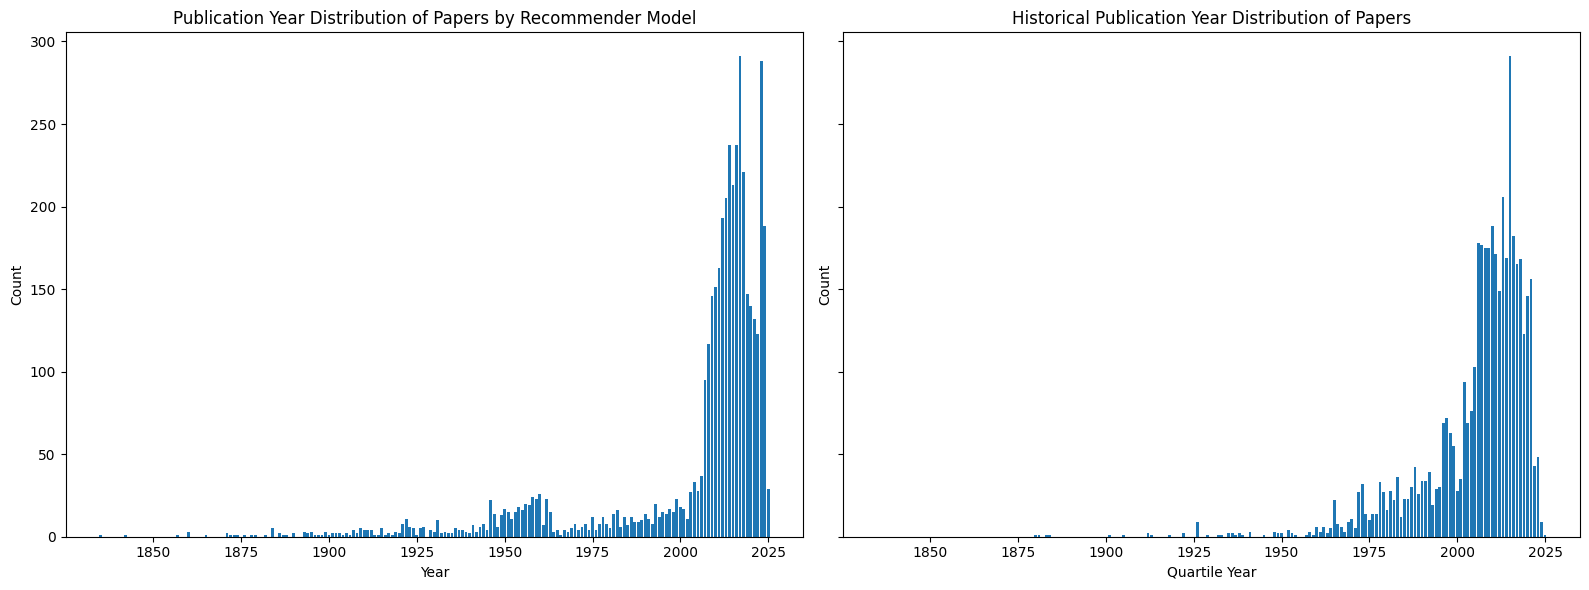

❇️ Topics


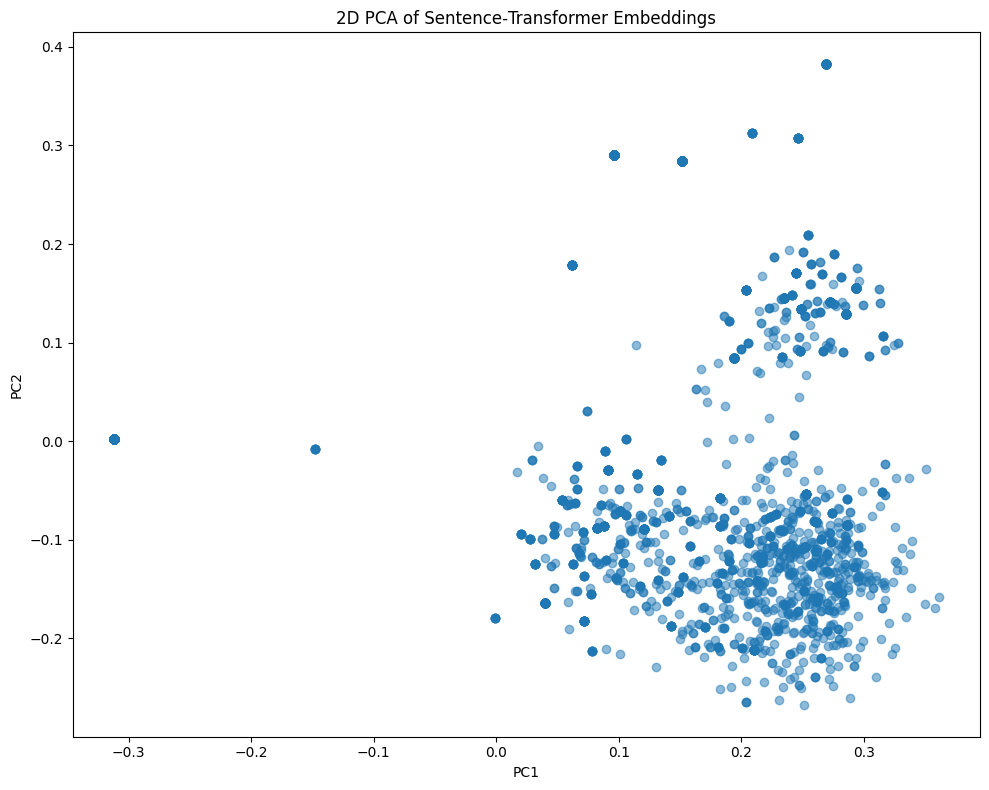

❇️ Novelty


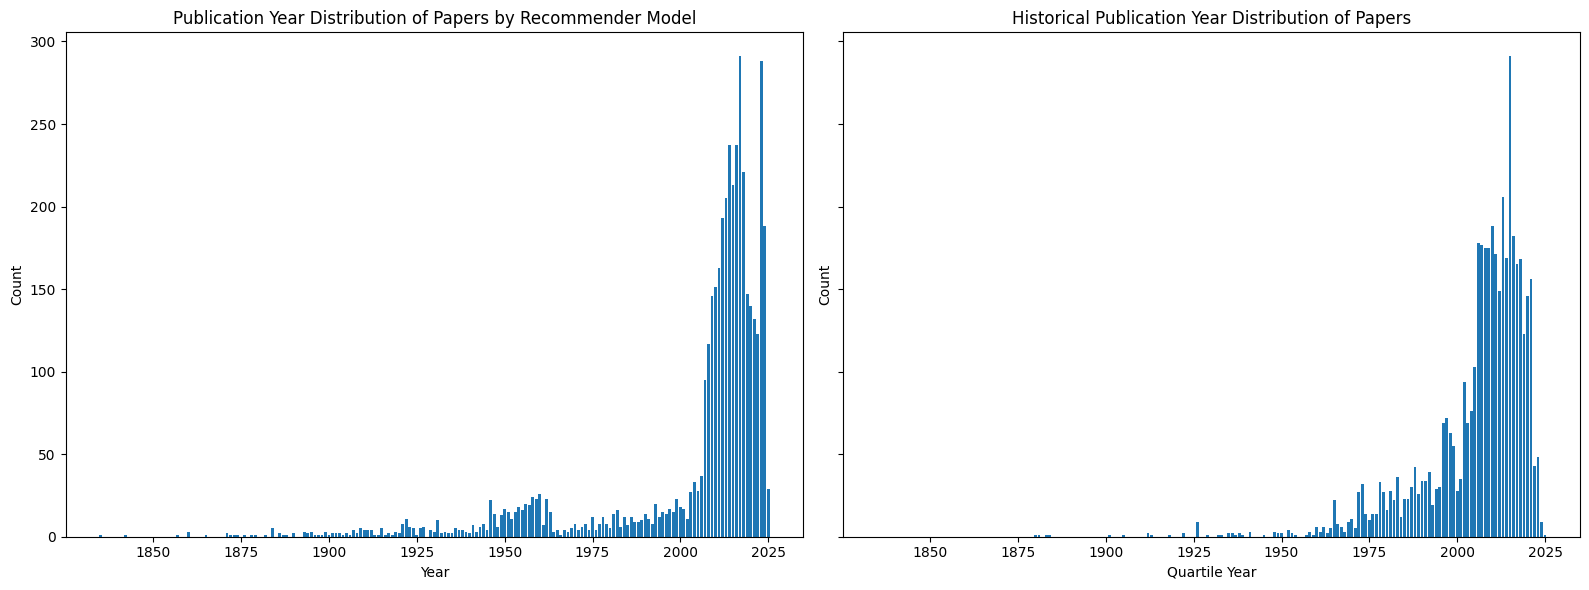

❇️ Reputability


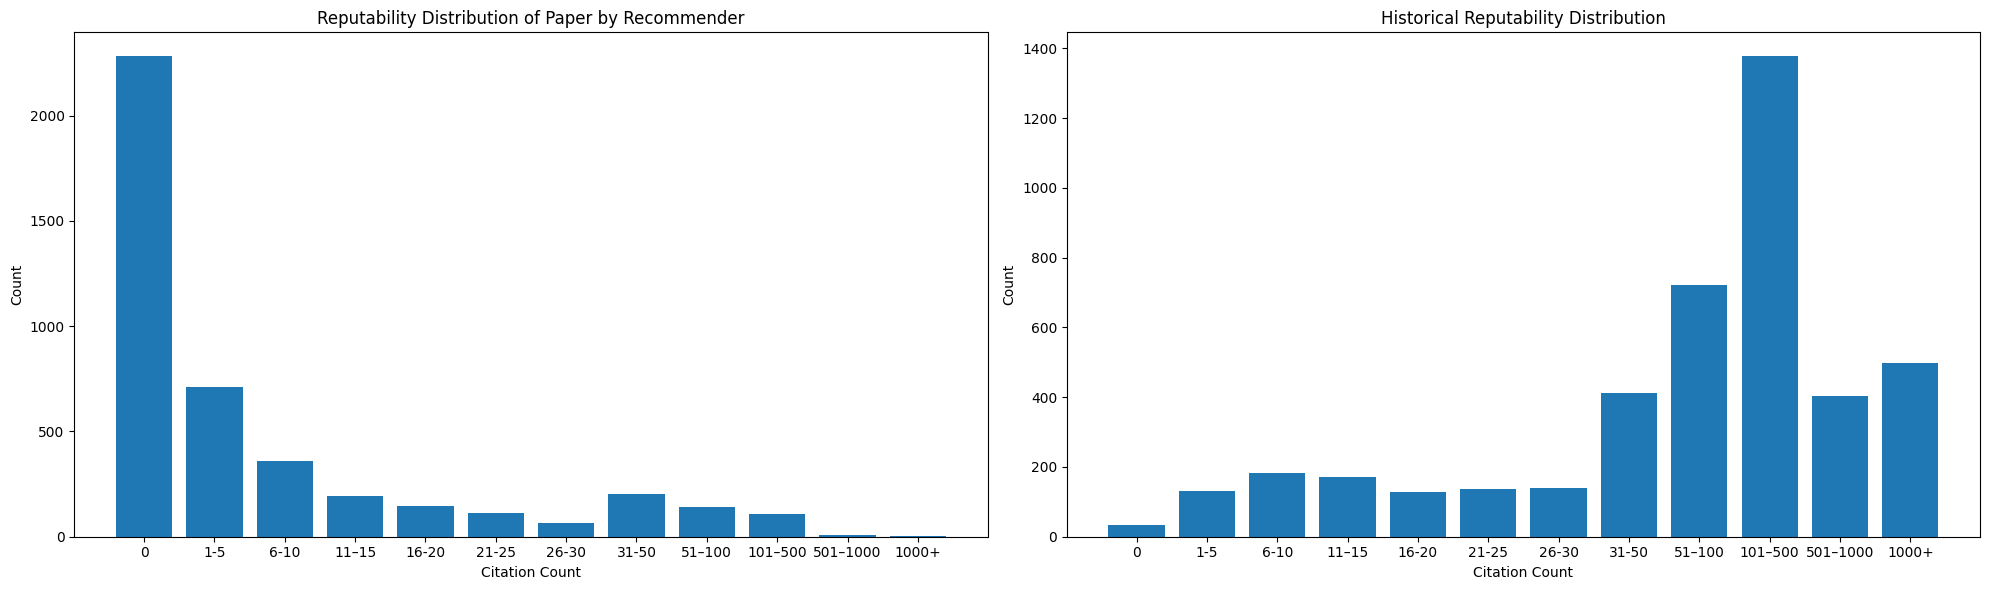

❇️ Overall


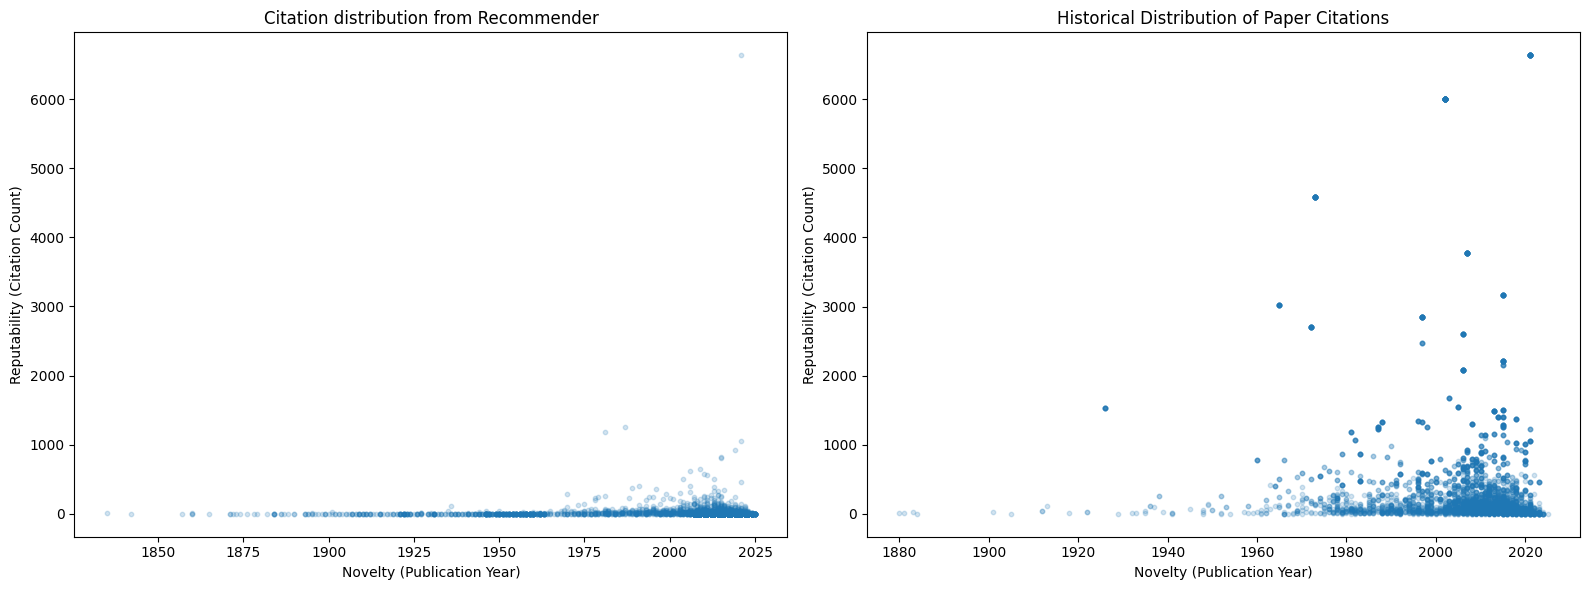

,id,title,publication_year,topics,topic_scorecommended_papers_df,cited_by_count,norm_cite,quartile_cite,norm_year,quartile_year,x,y
0,0,How to conduct a bibliometric analysis: An ove...,2021,[scientometrics and bibliometrics research],[0.9736],6635,1.000000,1.000000,0.996341,0.838384,-0.311892,0.002043
1,32771,"Diagnóstico de percepciones, actitudes, prácti...",2016,"[scientometrics and bibliometrics research, Ps...","[0.8525, 0.7695, 0.7505]",0,0.000000,0.000000,0.991677,0.626263,0.065939,-0.048553
2,24580,Institutional Repositories in Africa,2019,"[scientometrics and bibliometrics research, Ac...","[0.9927, 0.9069, 0.9056]",2,0.085497,0.580808,0.994488,0.777778,0.293265,0.155230
3,32773,Caracterização da produção científica portugue...,2016,"[scientometrics and bibliometrics research, Sc...","[0.9732, 0.9059]",0,0.000000,0.000000,0.991677,0.626263,0.082131,-0.087650
4,24579,What Do Citation Counts Measure? An Updated Re...,2019,"[scientometrics and bibliometrics research, Ad...","[0.9921, 0.9837, 0.9581]",2,0.085497,0.580808,0.994488,0.777778,0.157985,-0.106490
...,...,...,...,...,...,...,...,...,...,...,...,...
4334,40947,Disambiguation and Co-authorship Networks of t...,2011,[scientometrics and bibliometrics research],[0.9587],0,0.000000,0.000000,0.986906,0.368687,-0.311892,0.002043
4335,8181,Average-based versus high- and low-impact indi...,2011,[scientometrics and bibliometrics research],[0.9956],20,0.295771,0.858586,0.986906,0.368687,-0.311892,0.002043
4336,40953,Disambiguation and Co-authorship Networks of t...,2011,[scientometrics and bibliometrics research],[0.9663],0,0.000000,0.000000,0.986906,0.368687,-0.311892,0.002043
4337,16378,Supporting Knowledge Mobilization and Research...,2016,"[scientometrics and bibliometrics research, He...","[0.9884, 0.9757, 0.9205]",4,0.135510,0.666667,0.991677,0.626263,0.260976,-0.082505


In [133]:
def recommended_papers_analysis(reccommended_papers, paper_loader=paper_loader):
    all_rec_papers = []
    for papers in reccommended_papers:
        for user_id, recs in papers.items():
            all_rec_papers.extend(recs)

    all_rec_papers = list(set(all_rec_papers))

    items = paper_loader.load_items_from_ids(all_rec_papers)
    recommended_papers_df= pd.DataFrame()
    for item in items:
        row = {'id': item.id, 
        'title': item.title,
        'publication_year': item.year,
        'topics': item.topics,
        'topic_scorecommended_papers_df': item.topic_scores,
        'cited_by_count': item.cited_by_count,
        'norm_cite': item.norm_cite,
        'quartile_cite': item.quartile_cite,
        'norm_year': item.norm_year,
        'quartile_year': item.quartile_year       
        }
        recommended_papers_df= pd.concat([recommended_papers_df, pd.DataFrame([row])], ignore_index=True)
    print('Number of all recommended Papers:', len(recommended_papers_df))
    print('\n➡️ Number of Low cited papers', sum(recommended_papers_df.quartile_cite<=0.5))
    print(recommended_papers_df[recommended_papers_df.quartile_cite<=0.5].cited_by_count.value_counts())
    print('➡️ Number of New  papers', sum(recommended_papers_df.quartile_year>=0.73))
    print(recommended_papers_df[recommended_papers_df.quartile_year>=0.73].publication_year.value_counts())

    sampled_dataset = papersdf.sample(
    n=recommended_papers_df.shape[0],
    replace=True,                      # allow repeats
    weights='cited_by_count',          # use this column as relative weights
    random_state=42
     )
    


    print('\n❇️ Diversity')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
    ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Count")

    ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
    ax2.set_title("Historical Publication Year Distribution of Papers")
    ax2.set_xlabel("Quartile Year")
    ax2.set_ylabel("Count")

    plt.tight_layout()
    plt.show()



    print('❇️ Topics')
    bert_model = SentenceTransformer("all-MiniLM-L6-v2")
    all_embeddings = []
    for topics in recommended_papers_df['topics']:
        # get each topic’s 384‑d vector
        vecs = bert_model.encode(topics, convert_to_tensor=False)
        avg = np.mean(vecs, axis=0)
        all_embeddings.append(avg)

    embeddings = np.vstack(all_embeddings)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)

    recommended_papers_df['x'] = coords[:, 0]
    recommended_papers_df['y'] = coords[:, 1]

    plt.figure(figsize=(10, 8))
    plt.scatter(recommended_papers_df['x'], recommended_papers_df['y'], alpha=0.5)
    plt.title("2D PCA of Sentence‑Transformer Embeddings")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


    print('❇️ Novelty')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
    ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Count")

    ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
    ax2.set_title("Historical Publication Year Distribution of Papers")
    ax2.set_xlabel("Quartile Year")
    ax2.set_ylabel("Count")

    plt.tight_layout()
    plt.show()



    print('❇️ Reputability')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    bins = [0, 1, 5, 10, 15, 20, 25, 30, 50, 100, 500, 1000, recommended_papers_df['cited_by_count'].max()]
    labels = ['0', '1-5', '6-10', '11–15', '16-20', '21-25', '26-30', '31-50', '51–100', '101–500', '501–1000', '1000+']

    cited_by_count = pd.cut(recommended_papers_df['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

    ax1.bar(cited_by_count.index, cited_by_count.values)
    ax1.set_title("Reputability Distribution of Paper by Recommender")
    ax1.set_xlabel("Citation Count")
    ax1.set_ylabel("Count")

    dataset_cited_by_count = pd.cut(sampled_dataset['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

    ax2.bar(dataset_cited_by_count.index, dataset_cited_by_count.values)
    ax2.set_title("Historical Reputability Distribution")
    ax2.set_xlabel("Citation Count")
    ax2.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


    print('❇️ Overall')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.scatter(recommended_papers_df['publication_year'], recommended_papers_df['cited_by_count'], alpha=0.2, s=10)
    ax1.set_title("Citation distribution from Recommender")
    ax1.set_xlabel("Novelty (Publication Year)")
    ax1.set_ylabel("Reputability (Citation Count)")

    ax2.scatter(sampled_dataset['publication_year'], sampled_dataset['cited_by_count'], alpha=0.2, s=10)
    ax2.set_title("Historical Distribution of Paper Citations")
    ax2.set_xlabel("Novelty (Publication Year)")
    ax2.set_ylabel("Reputability (Citation Count)")

    plt.tight_layout()
    plt.show()
        
    return recommended_papers_df, sampled_dataset

recommended_papers_df, sampled_dataset = recommended_papers_analysis(reccommended_papers)
recommended_papers_df

A2C


,User,Precision per Session,Mean Precision,Cumulative Hit History
0,0,"[0.4, 0.3, 0.5, 0.5, 0.4, 0.9, 0.4, 0.7, 0.5, ...",0.566,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,1,"[0.6, 0.6, 0.8, 0.8, 0.7, 0.5, 0.4, 0.3, 0.6, ...",0.606,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,2,"[0.5, 0.7, 0.7, 0.6, 0.7, 0.6, 0.6, 0.7, 0.8, ...",0.662,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,3,"[0.6, 0.4, 0.8, 0.9, 0.4, 0.4, 0.4, 0.7, 0.5, ...",0.532,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,4,"[0.4, 0.8, 0.6, 0.7, 0.5, 0.5, 0.7, 0.7, 0.5, ...",0.602,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
5,5,"[0.7, 0.6, 0.5, 0.8, 0.7, 0.6, 0.8, 0.6, 0.4, ...",0.636,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
6,6,"[0.6, 0.3, 0.5, 0.6, 0.7, 0.7, 0.8, 0.7, 0.6, ...",0.642,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
7,7,"[0.6, 0.4, 0.4, 0.6, 0.9, 0.7, 0.6, 0.3, 0.6, ...",0.478,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
8,8,"[0.6, 0.5, 0.5, 0.4, 0.2, 0.4, 0.5, 0.7, 0.5, ...",0.446,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


Mean Precision@10 for all Users: 0.5744


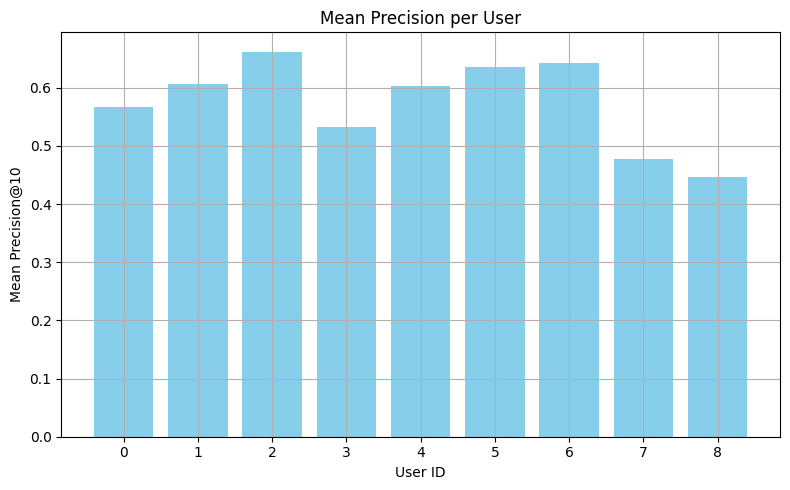

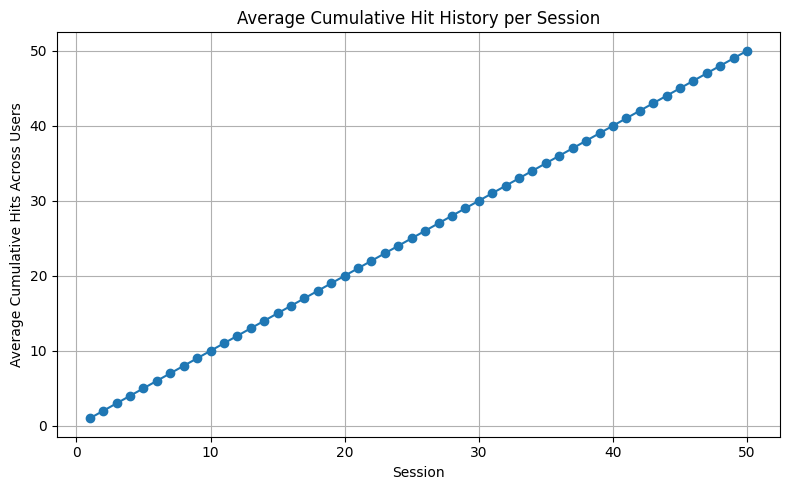

,Session,Users with ≥1 Hit,Total Users,Hit Rate@10,Temporal Hit Rate
0,1,9,9,1.0,1.0
1,2,9,9,1.0,1.0
2,3,9,9,1.0,1.0
3,4,9,9,1.0,1.0
4,5,9,9,1.0,1.0
5,6,9,9,1.0,1.0
6,7,9,9,1.0,1.0
7,8,9,9,1.0,1.0
8,9,9,9,1.0,1.0
9,10,9,9,1.0,1.0


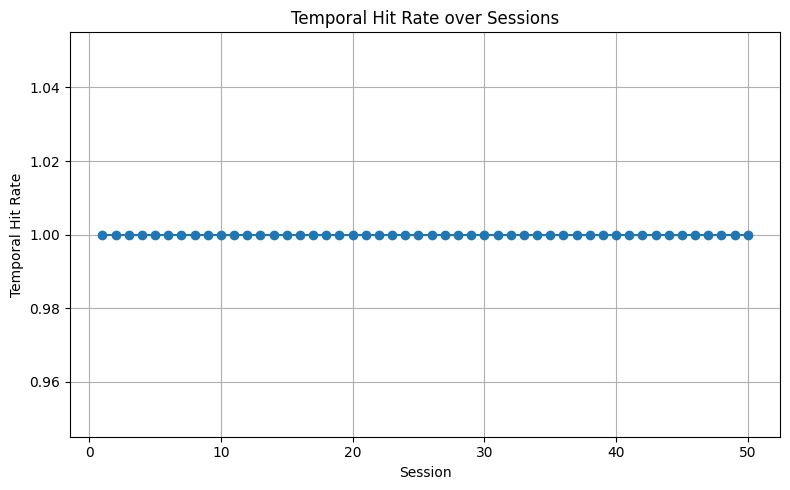

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def compute_precision_by_user(history_sessions, k=5):
    user_precisions = {}
    for session in history_sessions:
        for user, clicks in session.items():
            top_k_clicks = clicks[:k]
            precision = sum(top_k_clicks) / k
            if user not in user_precisions:
                user_precisions[user] = []
            user_precisions[user].append(precision)

    # Compute mean precision and cumulative hit rate
    summary = {
        "User": [],
        "Precision per Session": [],
        "Mean Precision": [],
        "Cumulative Hit History": []
    }
    for user, values in user_precisions.items():
        summary["User"].append(user)
        summary["Precision per Session"].append(values)
        summary["Mean Precision"].append(np.mean(values))
        cumulative_gt_zero = []
        count = 0
        for x in values:
            if x > 0:
                count += 1
            cumulative_gt_zero.append(count)
        summary["Cumulative Hit History"].append(cumulative_gt_zero)
    df = pd.DataFrame(summary)

   

    display(df)
    print(f"Mean Precision@{k} for all Users: {df['Mean Precision'].mean():.4f}")

    # Bar chart of mean precision per user
    plt.figure(figsize=(8, 5))
    plt.bar(df["User"], df["Mean Precision"], color='skyblue')
    plt.xlabel("User ID")
    plt.ylabel(f"Mean Precision@{k}")
    plt.title("Mean Precision per User")
    plt.xticks(df["User"])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    max_len = max(len(row["Cumulative Hit History"]) for _, row in df.iterrows())
    padded = np.zeros((len(df), max_len))

    for i, row in df.iterrows():
        padded[i, :len(row["Cumulative Hit History"])] = row["Cumulative Hit History"]

    average_cumulative_per_session = padded.mean(axis=0)

    # Plotting average cumulative hit history
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_len + 1), average_cumulative_per_session, marker='o')
    plt.xlabel("Session")
    plt.ylabel("Average Cumulative Hits Across Users")
    plt.title("Average Cumulative Hit History per Session")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df

def compute_hit_rate_with_plot(history_sessions, k=5):
    hit_rates = []
    cumulative_hit_count = 0
    clicked_user_counts = []

    for session in history_sessions:
        num_users = len(session)
        clicked_users = sum(any(session[user][j] for j in range(k)) for user in session)
        hit_rate = clicked_users / num_users
        hit_rates.append(hit_rate)
        clicked_user_counts.append(clicked_users)
        if clicked_users > 0:
            cumulative_hit_count += 1

    cumulative_hit_rate = cumulative_hit_count / len(history_sessions)
    temporal_hit_curve = np.cumsum(hit_rates) / np.arange(1, len(hit_rates) + 1)



    # DataFrame for inspection
    df = pd.DataFrame({
        "Session": np.arange(1, len(hit_rates) + 1),
        "Users with ≥1 Hit": clicked_user_counts,
        "Total Users": [len(session) for session in history_sessions],
        f"Hit Rate@{k}": hit_rates,
        "Temporal Hit Rate": temporal_hit_curve
    })
    display(df)

      # Line plot for Temporal Hit Rate
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, len(hit_rates) + 1), temporal_hit_curve, marker='o', linestyle='-')
    plt.xlabel("Session")
    plt.ylabel("Temporal Hit Rate")
    plt.title("Temporal Hit Rate over Sessions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df

print('A2C')
# Run both
precision_df = compute_precision_by_user(history_for_all_sessions, K)
hit_rate_df = compute_hit_rate_with_plot(history_for_all_sessions, K)


## PPO

In [135]:
model2 = A2C.load("models/PPO150k_citation_recommender_baseline", env=env, device="cpu")

Wrapping the env in a DummyVecEnv.


In [136]:
recommended_papers, history_for_all_sessions = simulate_user_clicks(model2)

0
Final score: (0.4826776332993279 + 0 + 0) / 3 = 0.1608925444331093
user = 0 - action = 23705 - rating = 0.1608925444331093 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6587162462180749 + 0.34 + 0.9595959595959596) / 3 = 0.6527707352713449
user = 0 - action = 8337 - rating = 0.6527707352713449 - click = 1 - interact_num = 1 - reward = 1.3055414705426898
Final score: (0.6518851885528039 + 0.15000000000000002 + 0.9078282828282829) / 3 = 0.5699044904603623
user = 0 - action = 24292 - rating = 0.5699044904603623 - click = 1 - interact_num = 1 - reward = 1.1398089809207246
Final score: (0.6540942848894491 + 0.34 + 0.9166666666666667) / 3 = 0.636920317185372
user = 0 - action = 16906 - rating = 0.636920317185372 - click = 1 - interact_num = 1 - reward = 1.273840634370744
Final score: (0.3721385157761856 + 0 + 0) / 3 = 0.1240461719253952
user = 0 - action = 17968 - rating = 0.1240461719253952 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6572131668465131 + 

/var/folders/_f/s0xx4_bj711c1h8k9b5vjhgm0000gn/T/ipykernel_87846/2804152994.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


user = 0 - action = 19904 - rating = 0.5723033788478276 - click = 1 - interact_num = 1 - reward = 1.1446067576956551
Final score: (0.4175295837321369 + 0 + 0) / 3 = 0.1391765279107123
user = 0 - action = 44826 - rating = 0.1391765279107123 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.616153167987362 + 0.34 + 0.928030303030303) / 3 = 0.6280611570058884
user = 0 - action = 14436 - rating = 0.6280611570058884 - click = 1 - interact_num = 1 - reward = 1.2561223140117768
Final score: (0.3573559313484227 + 0 + 0) / 3 = 0.11911864378280757
user = 0 - action = 30431 - rating = 0.11911864378280757 - click = 0 - interact_num = 1 - reward = -0.5
Final score: (0.6560309943537306 + 0.5333333333333334 + 0.9419191919191919) / 3 = 0.710427839868752
user = 0 - action = 11906 - rating = 0.710427839868752 - click = 1 - interact_num = 1 - reward = 1.420855679737504
Final score: (0.613715453003089 + 0.5333333333333334 + 0.875) / 3 = 0.6740162621121408
user = 1 - action = 28987 - rating = 

In [137]:
recommended_papers

[{0: (23705, 8337, 24292, 16906, 17968, 19904, 44826, 14436, 30431, 11906),
  1: (28987, 6569, 20744, 44812, 29635, 35571, 21178, 12436, 9501, 40819),
  2: (17856, 48180, 14906, 24481, 13410, 6159, 27189, 4994, 7685, 36321),
  3: (28932, 15342, 36773, 7142, 27249, 43292, 38555, 17794, 29375, 40932),
  4: (20452, 4244, 40327, 37747, 15234, 37395, 21784, 14820, 46697, 34981),
  5: (44463, 914, 37522, 44168, 42854, 6192, 2461, 23161, 6954, 38641),
  6: (7736, 12362, 16181, 31391, 29668, 20389, 4986, 17579, 11384, 27430),
  7: (25908, 46234, 44544, 14112, 47312, 32102, 48863, 5806, 38957, 43328),
  8: (18755, 6416, 9104, 29887, 8806, 7257, 14719, 17955, 37542, 2214)},
 {0: (35774, 45343, 20936, 46796, 10970, 14995, 34729, 3197, 14309, 9431),
  1: (1909, 48138, 10654, 7932, 34376, 1994, 12012, 38412, 25653, 32035),
  2: (28896, 29985, 11864, 2929, 152, 1163, 10414, 1525, 18525, 1785),
  3: (34950, 26521, 35020, 18509, 24621, 40317, 27792, 3852, 12773, 12031),
  4: (5265, 40627, 10513, 33748

Number of all recommended Papers: 4251

➡️ Number of Low cited papers 2158
cited_by_count
0    1724
1     434
Name: count, dtype: int64
➡️ Number of New  papers 1338
publication_year
2023    294
2018    250
2024    193
2020    174
2019    153
2022    133
2021    122
2025     19
Name: count, dtype: int64

❇️ Diversity


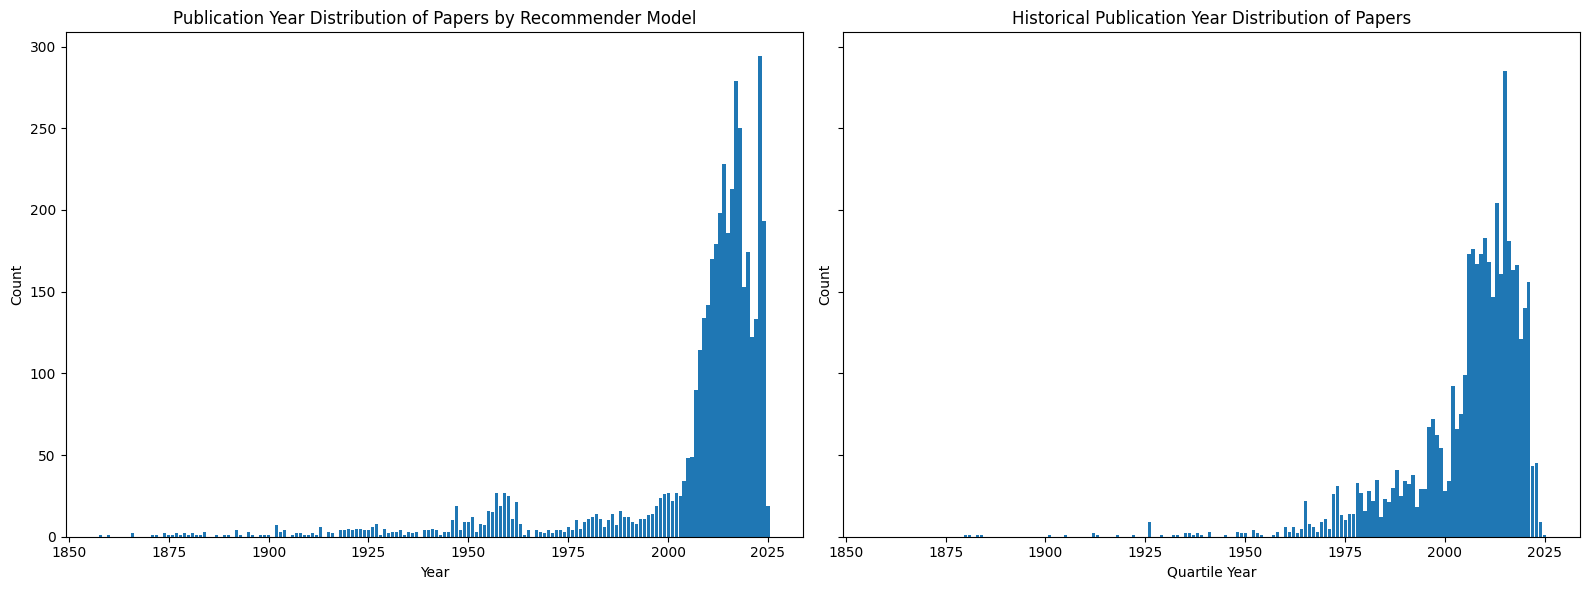

❇️ Topics


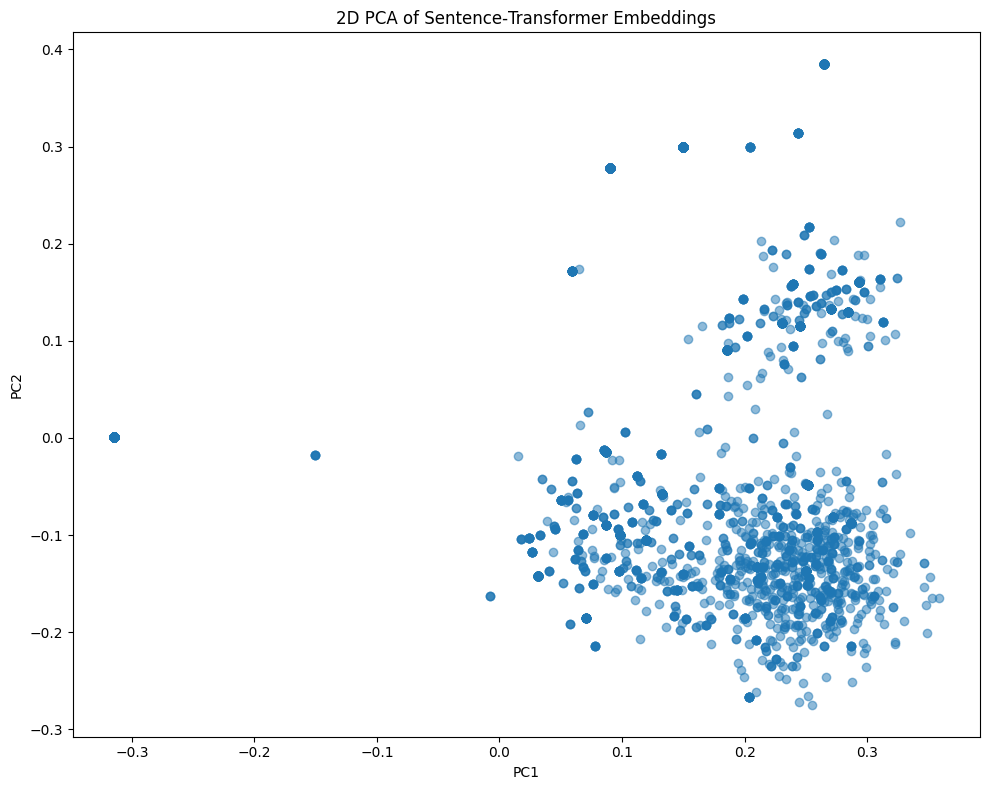

❇️ Novelty


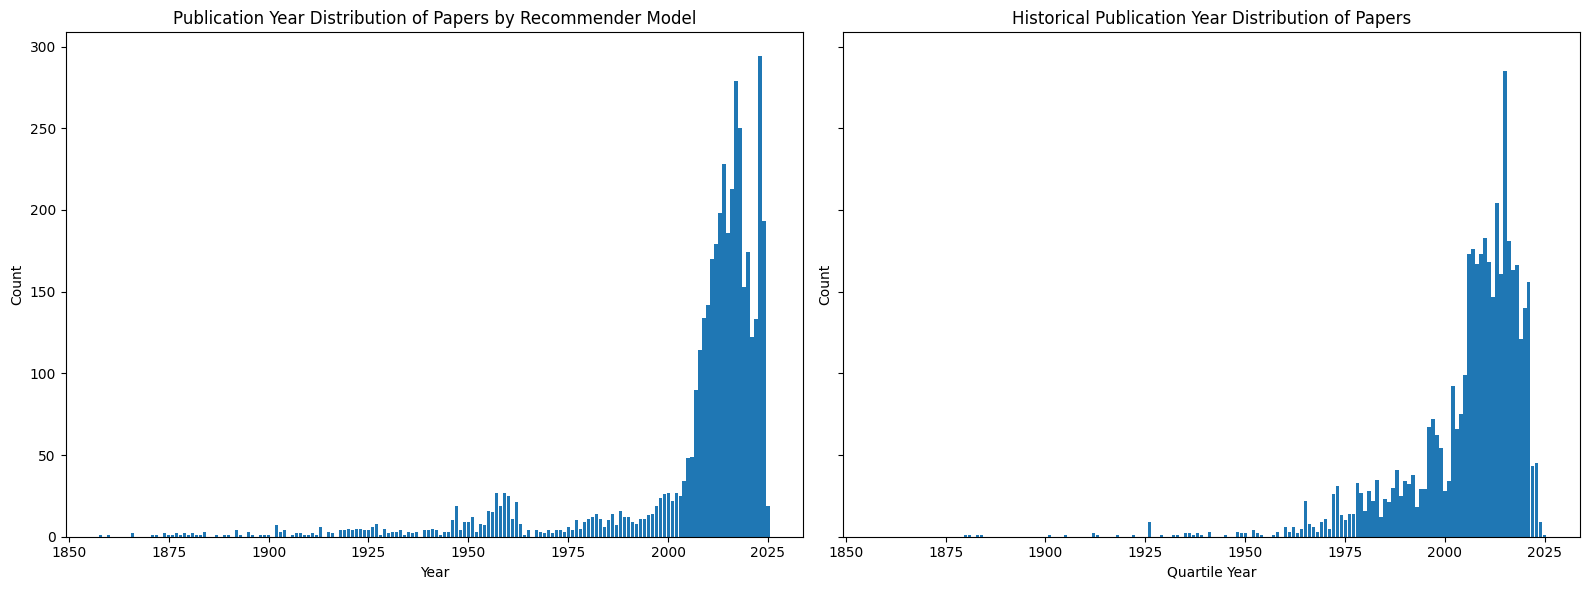

❇️ Reputability


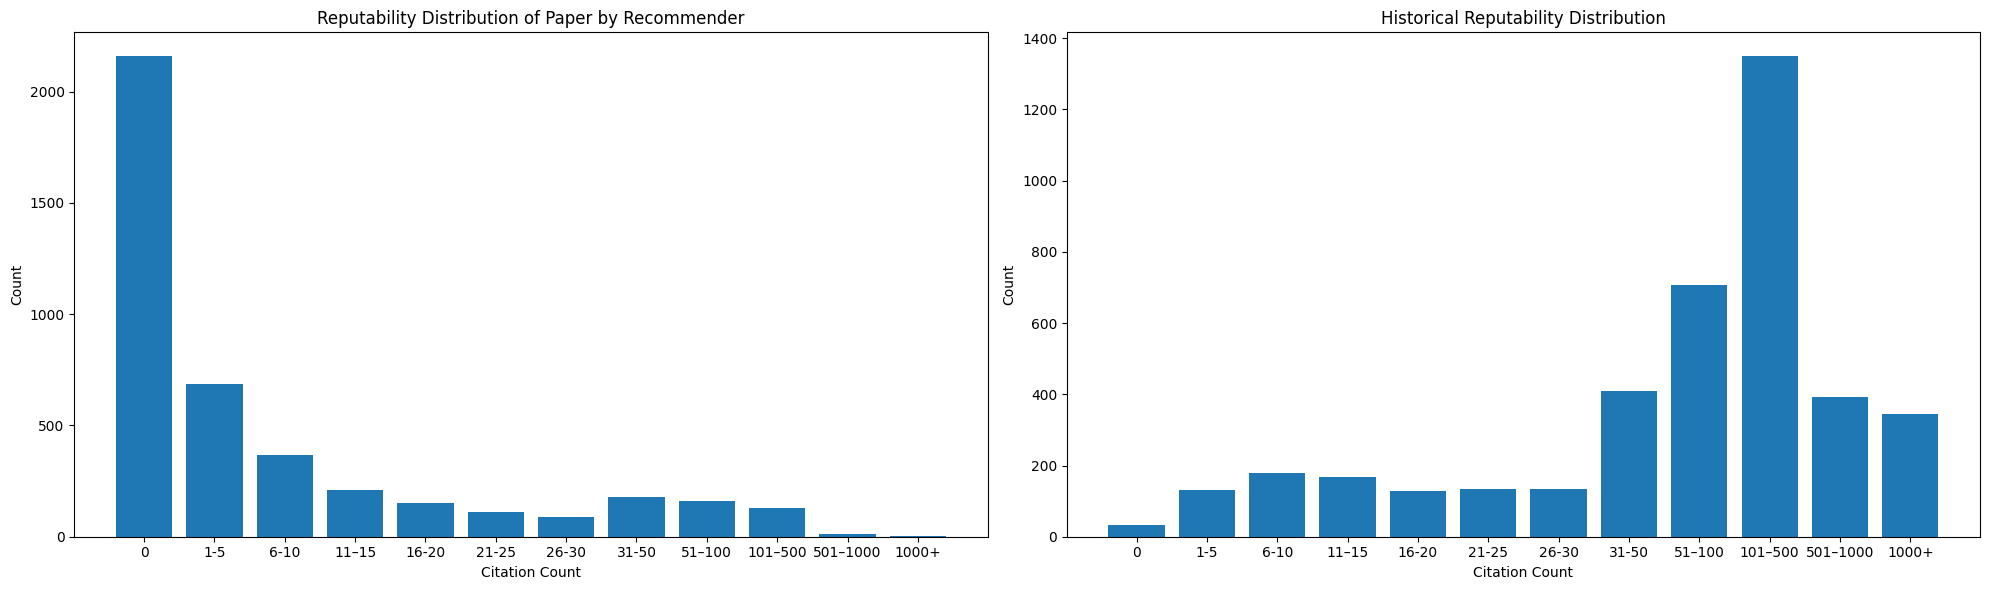

❇️ Overall


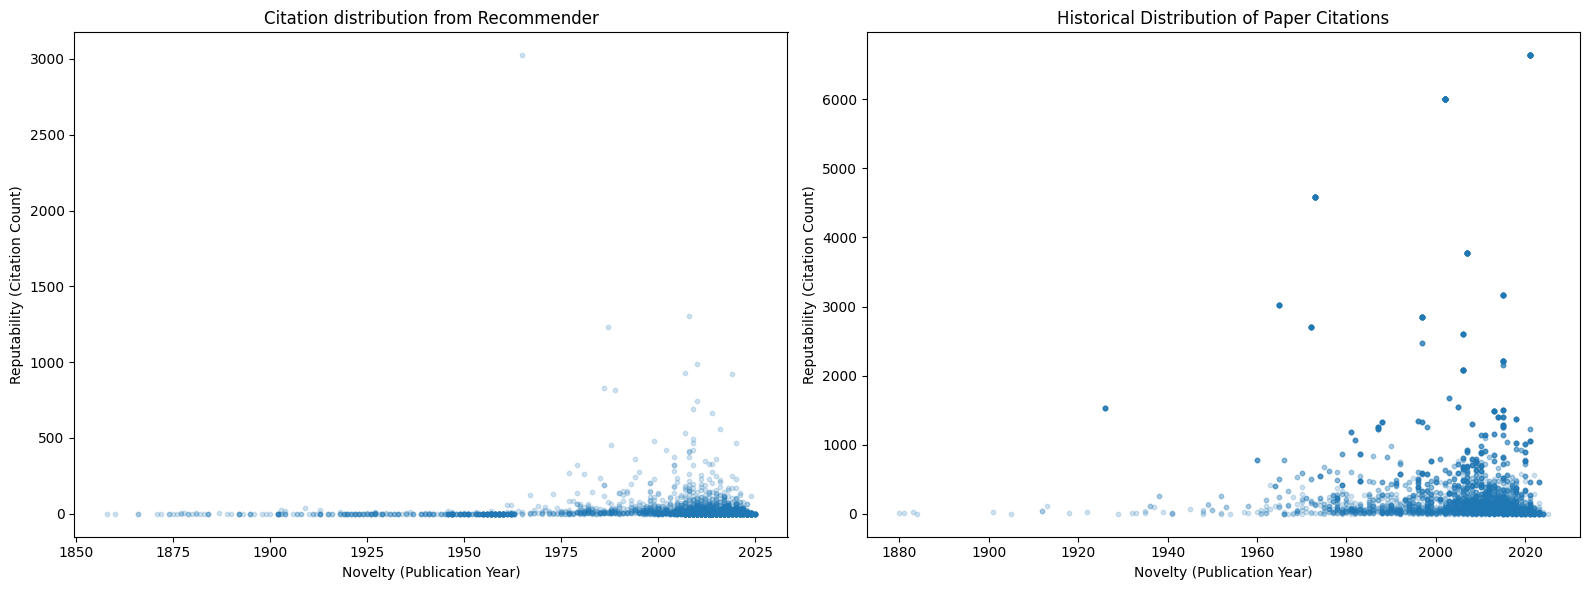

In [138]:
recommended_papers_df, sampled_dataset = recommended_papers_analysis(recommended_papers)

PPO


,User,Precision per Session,Mean Precision,Cumulative Hit History
0,0,"[0.6, 0.9, 0.5, 0.5, 0.9, 0.6, 0.7, 0.7, 0.6, ...",0.628,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,1,"[0.7, 0.6, 0.7, 0.6, 0.8, 0.7, 0.6, 0.7, 0.8, ...",0.644,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,2,"[0.8, 0.8, 0.7, 0.7, 1.0, 0.7, 0.9, 1.0, 0.7, ...",0.720,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,3,"[0.4, 0.7, 0.7, 0.8, 0.7, 0.5, 0.6, 0.4, 0.7, ...",0.658,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,4,"[0.7, 0.5, 0.8, 0.8, 0.7, 0.7, 0.6, 0.6, 0.5, ...",0.638,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
5,5,"[0.6, 0.6, 0.8, 0.8, 0.8, 0.7, 0.8, 0.6, 0.6, ...",0.656,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
6,6,"[1.0, 0.5, 0.3, 0.5, 0.6, 0.3, 0.3, 0.3, 0.8, ...",0.616,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
7,7,"[0.3, 0.6, 0.9, 0.6, 0.4, 0.6, 0.7, 0.3, 0.6, ...",0.550,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
8,8,"[0.5, 0.6, 0.7, 0.6, 0.5, 0.3, 0.9, 0.6, 0.7, ...",0.488,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


Mean Precision@10 for all Users: 0.6220


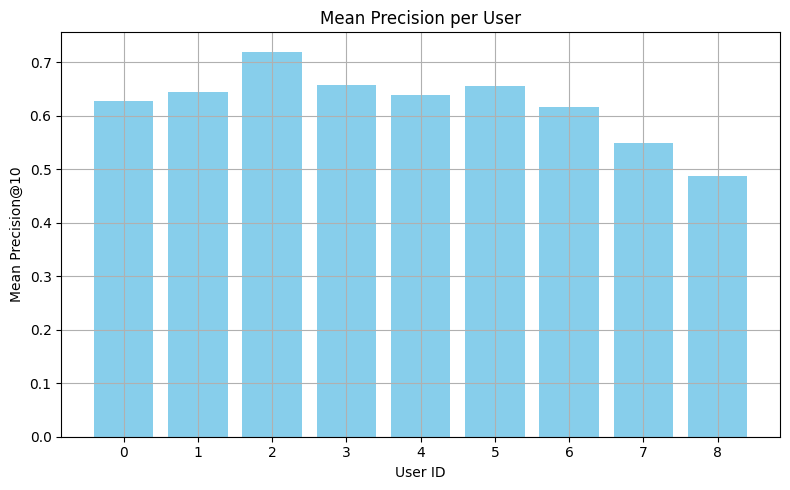

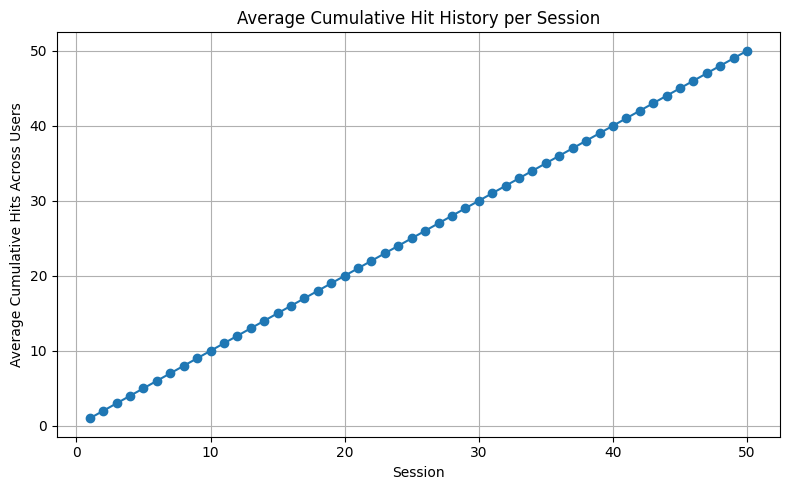

,Session,Users with ≥1 Hit,Total Users,Hit Rate@10,Temporal Hit Rate
0,1,9,9,1.0,1.0
1,2,9,9,1.0,1.0
2,3,9,9,1.0,1.0
3,4,9,9,1.0,1.0
4,5,9,9,1.0,1.0
5,6,9,9,1.0,1.0
6,7,9,9,1.0,1.0
7,8,9,9,1.0,1.0
8,9,9,9,1.0,1.0
9,10,9,9,1.0,1.0


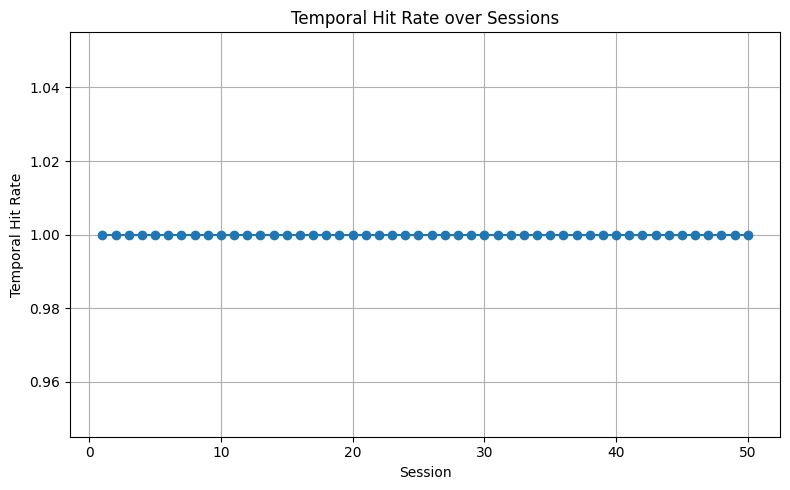

In [139]:
print('PPO')
# Run both
precision_df = compute_precision_by_user(history_for_all_sessions, K)
hit_rate_df = compute_hit_rate_with_plot(history_for_all_sessions, K)

### DQN

In [141]:
# env = UserEnv(
#         render_mode= "human",
#         debug=False,
#         debug_path="debug_log/user_env_DQN_eval.log",
#         items_loader=paper_loader,
#         user_list=all_users,
#         items_selector=selector,
#         reward_shaping=reward_shaping,
#         render_path="./tmp/render/",
#         max_interactions=200,
# )
# env = Monitor(env, filename=f"monitor_DQN_user_eval.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
eval_model = DQN.load("models/random_dqn_citation_recommender", env=env, device="cpu")

ModuleNotFoundError: No module named 'numpy._core.numeric'

In [ ]:
recommended_papers, history_for_all_sessions = simulate_user_clicks(model2)